# Context
Trying to improve the outlier detection function at 575nm. My idea, instead to look for the difference between the gradient and the average gradient around, to look for the slope before and after. If the slope is similar (param to determine), the spectrum can be stitched. If not, the spectrum is outlier. 

run 009A seems a good candidate to start

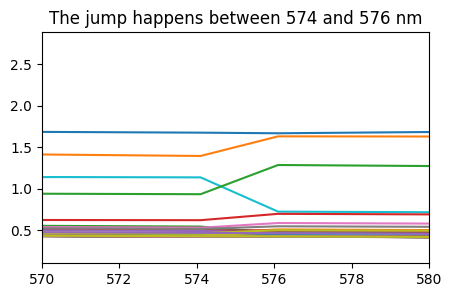

In [11]:
from custom_tools.acs_data_reader import get_acs_IOP
import matplotlib.pyplot as plt
import numpy as np
import os
import warnings
warnings.filterwarnings("ignore")

dir_path = "../data/raw/1_acs_runs/runs"
f = "run_21_ACS.009"

df_arr_A, df_arr_C = get_acs_IOP(os.path.join(dir_path, f))
wav_A = np.array(df_arr_A.columns.astype(float))
wav_C = np.array(df_arr_C.columns.astype(float))

fig, ax = plt.subplots(figsize = (5, 3))

for i, sp in df_arr_A.iterrows():
    ax.plot(wav_A, sp)

ax.set_xlim([570, 580])
plt.title("The jump happens between 574 and 576 nm")
plt.show()

In [13]:
wav_A

array([400.5, 403.7, 407.3, 410.1, 413.5, 417.1, 421.2, 425.3, 429.3,
       432.9, 436.4, 440. , 444.2, 448.6, 453. , 457.1, 460.6, 464.8,
       469.1, 473.4, 478. , 482.4, 486.7, 490.6, 494.6, 498.4, 502.6,
       507.1, 511.6, 516.5, 520.8, 524.9, 528.9, 532.9, 536.8, 540.8,
       544.9, 549.3, 553.8, 558.1, 562.3, 566.8, 570.3, 574.1, 576.1,
       579.8, 583.7, 587.6, 591.7, 596. , 600.4, 604.6, 609.2, 613.8,
       618.4, 622.7, 627. , 630.9, 634.9, 639.3, 643.6, 647.8, 652.1,
       656.8, 661.3, 665.7, 670.1, 674.5, 678.8, 682.7, 686.8, 690.7,
       694.5, 698.1, 701.8, 705.5, 709.1, 712.9, 716.8, 720.3, 724. ,
       727.5, 731. , 734. , 738. ])

The transition wavelength are 574.1, 576.1

Lets look at the gradient around 575 nm

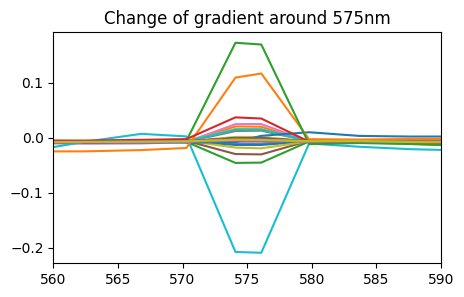

In [16]:

fig, ax = plt.subplots(figsize = (5, 3))

for i, sp in df_arr_A.iterrows():
    deriv_spectrum = np.gradient(sp)
    ax.plot(wav_A, deriv_spectrum)

ax.set_xlim([560, 590])
plt.title("Change of gradient around 575nm")
plt.show()



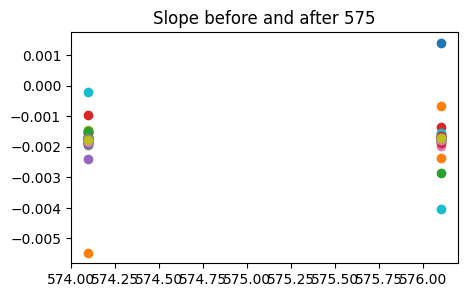

In [18]:
import numpy as np

def calculate_stitch_slopes(wav, sp, target_wav_pre=574.1, target_wav_post=576.1, n=5):
    """
    Calculates the slopes of the spectrum at two specific points.
    
    Parameters:
    wav: Array of wavelengths
    sp: Array of spectral intensities
    target_wav_pre: The 'end' wavelength of the first segment
    target_wav_post: The 'start' wavelength of the second segment
    n: Number of points to include in the slope calculation
    """
    
    # 1. Find the index for the 'pre' point (wavelength <= 574.1)
    # We take the last n points leading up to and including this index
    idx_pre = np.where(wav <= target_wav_pre)[0][-1]
    wav_pre_seg = wav[idx_pre - n + 1 : idx_pre + 1]
    sp_pre_seg = sp[idx_pre - n + 1 : idx_pre + 1]
    
    # 2. Find the index for the 'post' point (wavelength >= 576.1)
    # We take the first n points starting from this index
    idx_post = np.where(wav >= target_wav_post)[0][0]
    wav_post_seg = wav[idx_post : idx_post + n]
    sp_post_seg = sp[idx_post : idx_post + n]
    
    # Calculate slopes using a first-order polynomial fit (linear)
    # np.polyfit returns [slope, intercept]
    slope_pre = np.polyfit(wav_pre_seg, sp_pre_seg, 1)[0]
    slope_post = np.polyfit(wav_post_seg, sp_post_seg, 1)[0]
    
    slope_abs_diff = np.abs(slope_pre-slope_post)
    return slope_pre, slope_post, slope_abs_diff

fig, ax = plt.subplots(figsize = (5, 3))

for i, sp in df_arr_A.iterrows():
    slope_pre, slope_post, _ = calculate_stitch_slopes(wav_A, sp, target_wav_pre=574.1, target_wav_post=576.1, n=5)
    ax.scatter([574.1, 576.1], [slope_pre, slope_post])

plt.title("Slope before and after 575")
plt.show()

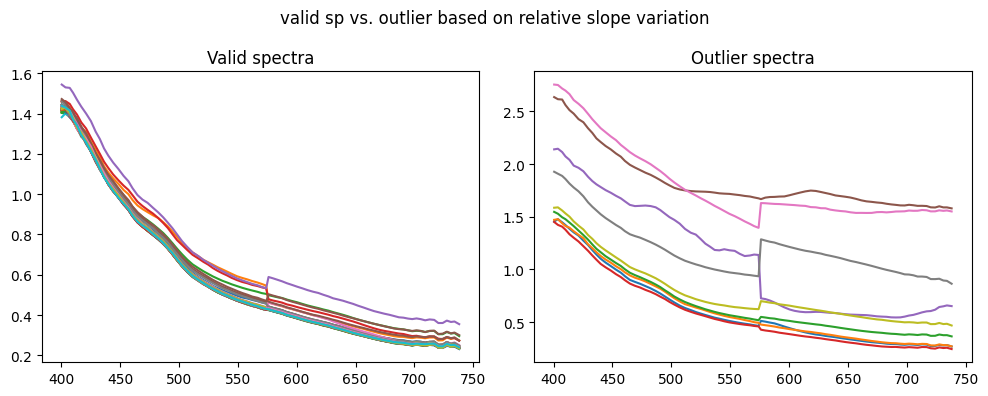

In [28]:
def check_stitch_validity(slope_pre, slope_post, threshold=0.1):
    """
    Determines if a stitch is valid based on the relative difference 
    between two slopes.
    
    Parameters:
    slope_pre: Slope of the segment before the gap
    slope_post: Slope of the segment after the gap
    threshold: Max allowed relative change (0.15 = 15%)
    
    Returns:
    is_valid: Boolean (True if stitch is okay, False if outlier)
    rel_diff: The calculated relative difference
    """
    
    # Calculate the absolute difference
    abs_diff = np.abs(slope_pre - slope_post)
    
    # Calculate the average magnitude of the slopes
    # Adding 1e-9 (epsilon) to prevent division by zero
    avg_mag = (np.abs(slope_pre) + np.abs(slope_post)) / 2.0 + 1e-9
    
    # Calculate relative difference
    rel_diff = abs_diff / avg_mag
    
    # Valid if the change is below the threshold
    is_valid = rel_diff <= threshold
    
    return is_valid, rel_diff


fig, ax = plt.subplots(ncols=2, figsize = (10, 4))

for i, sp in df_arr_A.iterrows():
    slope_pre, slope_post, slope_abs_diff = calculate_stitch_slopes(wav_A, sp, target_wav_pre=574.1, target_wav_post=576.1, n=5)
    is_valid, rel_diff = check_stitch_validity(slope_pre, slope_post, threshold=0.2)
    if is_valid:
        ax[0].plot(wav_A, sp)
    else:
        ax[1].plot(wav_A, sp)
        
ax[0].set_title("Valid spectra")
ax[1].set_title("Outlier spectra")
plt.suptitle(f"valid sp vs. outlier based on relative slope variation")
plt.tight_layout()
plt.show()

In [29]:
import numpy as np

def apply_stitch_offset(wav, sp, target_wav_pre=574.1, target_wav_post=576.1, n=5):
    """
    Calculates the vertical offset at the gap midpoint and applies it 
    to all values above the gap.
    """
    # 1. Get segments for fitting (same logic as before)
    idx_pre = np.where(wav <= target_wav_pre)[0][-1]
    wav_pre_seg = wav[idx_pre - n + 1 : idx_pre + 1]
    sp_pre_seg = sp[idx_pre - n + 1 : idx_pre + 1]
    
    idx_post = np.where(wav >= target_wav_post)[0][0]
    wav_post_seg = wav[idx_post : idx_post + n]
    sp_post_seg = sp[idx_post : idx_post + n]
    
    # 2. Linear fits: y = mx + c
    m_pre, c_pre = np.polyfit(wav_pre_seg, sp_pre_seg, 1)
    m_post, c_post = np.polyfit(wav_post_seg, sp_post_seg, 1)
    
    # 3. Extrapolate to the midpoint of the gap
    x_mid = (target_wav_pre + target_wav_post) / 2.0
    y_pre_mid = m_pre * x_mid + c_pre
    y_post_mid = m_post * x_mid + c_post
    
    # 4. Calculate the required shift
    offset = y_pre_mid - y_post_mid
    
    # 5. Apply the offset to all values above the gap
    sp_stitched = sp.copy()
    sp_stitched[wav >= target_wav_post] += offset
    
    return sp_stitched, offset



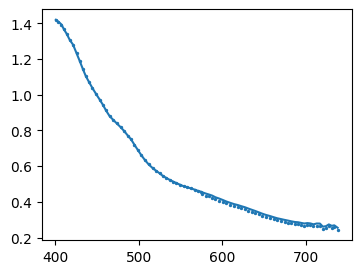

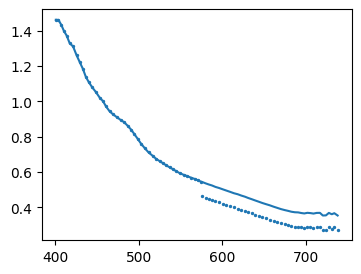

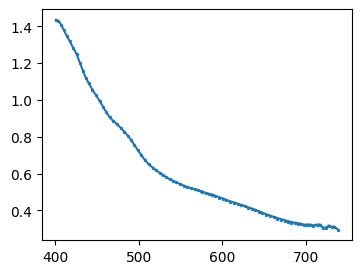

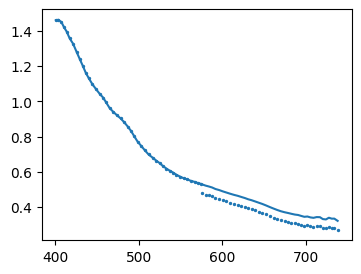

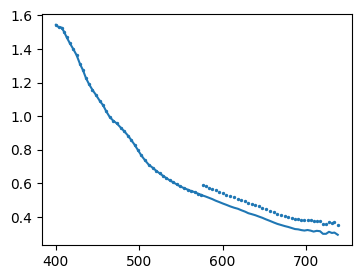

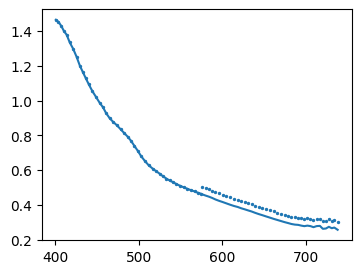

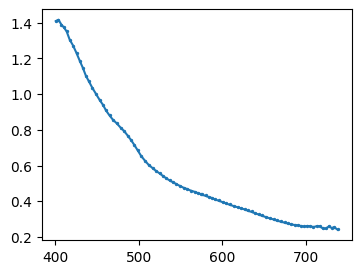

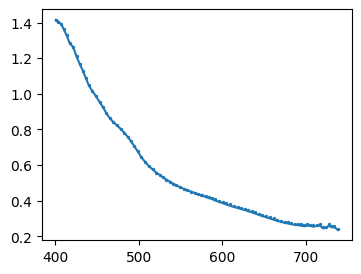

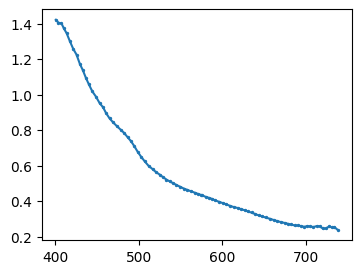

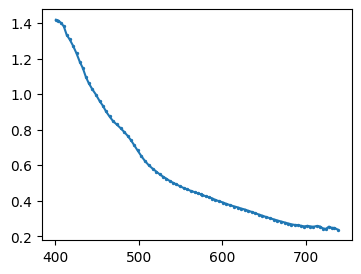

In [31]:
n_plot_max = 10
n=0

for i, sp in df_arr_A.iterrows():
    slope_pre, slope_post, slope_abs_diff = calculate_stitch_slopes(wav_A, sp, target_wav_pre=574.1, target_wav_post=576.1, n=5)
    is_valid, rel_diff = check_stitch_validity(slope_pre, slope_post, threshold=0.2)
    if is_valid and n<n_plot_max:
        sp_stiched, offset = apply_stitch_offset(wav_A, sp, target_wav_pre=574.1, target_wav_post=576.1, n=5)
        fig, ax = plt.subplots(figsize = (4, 3))
        ax.scatter(wav_A, sp, label = "before stitching", s=2)
        ax.plot(wav_A, sp_stiched, label = "after stitching")
        plt.show()
        
        n += 1

# wavelength for scattering spectra


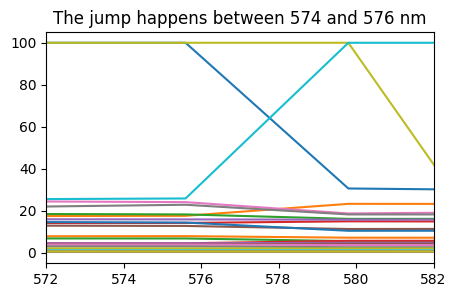

In [34]:
from custom_tools.acs_data_reader import get_acs_IOP
import matplotlib.pyplot as plt
import numpy as np
import os
import warnings
warnings.filterwarnings("ignore")

dir_path = "../data/raw/1_acs_runs/runs"
f = "run_21_ACS.011"

df_arr_A, df_arr_S = get_acs_IOP(os.path.join(dir_path, f))
wav_A = np.array(df_arr_A.columns.astype(float))
wav_S = np.array(df_arr_C.columns.astype(float))

fig, ax = plt.subplots(figsize = (5, 3))

for i, sp in df_arr_S.iterrows():
    ax.plot(wav_S, sp)

ax.set_xlim([572, 582])
plt.title("The jump happens between 574 and 576 nm")
plt.show()

In [35]:
wav_S

array([401. , 404.6, 407.8, 411.2, 414.4, 418.2, 422.2, 426.3, 430.2,
       433.6, 437.5, 441.2, 445.5, 449.9, 454.1, 458. , 461.7, 466.1,
       470.3, 474.8, 479.6, 483.9, 488.3, 492. , 496. , 499.8, 504. ,
       508.8, 513.3, 517.8, 522.5, 526.5, 530.6, 534.4, 538.5, 542.3,
       546.4, 550.9, 555.5, 559.8, 564. , 568.1, 571.9, 575.6, 579.8,
       583.6, 587.8, 591.7, 596. , 600.4, 604.8, 609.3, 614.2, 618.7,
       622.9, 627.2, 631. , 635. , 639.5, 643.8, 648.1, 652.7, 657.5,
       661.9, 666.4, 670.6, 675. , 679.3, 683.3, 687.2, 691. , 695.2,
       698.7, 702.5, 706.3, 709.9, 713.7, 717.4, 721.1, 724.8, 728. ,
       731.6, 735. , 738.3, 742.4])

the wavelength for S are: [575.6, 579.8]

In [37]:
def detect_stitch_wavelengths(wav, gap_center=576.0):
    """
    Finds the wavelengths in the array immediately before and after the gap_center.
    """
    # Find the index where gap_center would be inserted to maintain order
    idx_post = np.searchsorted(wav, gap_center)
    
    # The 'pre' index is the one immediately before it
    idx_pre = idx_post - 1
    
    # Boundary checks to ensure the center isn't outside the spectral range
    if idx_post >= len(wav) or idx_pre < 0:
        raise ValueError(f"Gap center {gap_center} is outside the range of the wavelength array.")
        
    target_wav_pre = wav[idx_pre]
    target_wav_post = wav[idx_post]
    
    return target_wav_pre, target_wav_post

detect_stitch_wavelengths(wav_S)

(np.float64(575.6), np.float64(579.8))